In [1]:
import pandas as pd

df = pd.read_csv('/content/test (1).csv')
print(df.head())
print(df['label'].value_counts())


                                                text  label
0  im feeling rather rotten so im not very ambiti...      0
1          im updating my blog because i feel shitty      0
2  i never make her separate from me because i do...      0
3  i left with my bouquet of red and yellow tulip...      1
4    i was feeling a little vain when i did this one      0
label
1    695
0    581
3    275
4    224
2    159
5     66
Name: count, dtype: int64


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
import re

def clean_text(text):
    text = re.sub(r"http\S+|@\S+|#\S+", "", text)
    text = re.sub(r"[^\w\s]", "", text.lower())
    return text

df['clean_text'] = df['text'].apply(clean_text)

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_text'])


In [3]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['label'])


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

kernels = ['linear', 'rbf', 'poly', 'sigmoid']
for kernel in kernels:
    print(f"\nTraining with {kernel} kernel...")
    clf = SVC(kernel=kernel)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    target_names_str = [str(cls) for cls in le.classes_]
    print(f"Classification report for {kernel} kernel:\n", classification_report(y_test, y_pred, target_names=target_names_str))


Training with linear kernel...


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification report for linear kernel:
               precision    recall  f1-score   support

           0       0.72      0.80      0.76       124
           1       0.57      0.94      0.71       131
           2       1.00      0.06      0.11        35
           3       0.80      0.38      0.52        52
           4       0.71      0.35      0.47        43
           5       0.00      0.00      0.00        15

    accuracy                           0.65       400
   macro avg       0.63      0.42      0.43       400
weighted avg       0.68      0.65      0.60       400


Training with rbf kernel...


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification report for rbf kernel:
               precision    recall  f1-score   support

           0       0.60      0.67      0.63       124
           1       0.48      0.94      0.64       131
           2       0.00      0.00      0.00        35
           3       1.00      0.06      0.11        52
           4       1.00      0.07      0.13        43
           5       0.00      0.00      0.00        15

    accuracy                           0.53       400
   macro avg       0.51      0.29      0.25       400
weighted avg       0.58      0.53      0.43       400


Training with poly kernel...


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification report for poly kernel:
               precision    recall  f1-score   support

           0       0.88      0.12      0.21       124
           1       0.34      1.00      0.51       131
           2       0.00      0.00      0.00        35
           3       0.00      0.00      0.00        52
           4       0.00      0.00      0.00        43
           5       0.00      0.00      0.00        15

    accuracy                           0.36       400
   macro avg       0.20      0.19      0.12       400
weighted avg       0.39      0.36      0.23       400


Training with sigmoid kernel...
Classification report for sigmoid kernel:
               precision    recall  f1-score   support

           0       0.71      0.79      0.75       124
           1       0.56      0.94      0.70       131
           2       1.00      0.03      0.06        35
           3       0.83      0.37      0.51        52
           4       0.74      0.33      0.45        43
           5    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Training with linear kernel...
Classification report for linear kernel:

              precision    recall  f1-score   support

           0       0.72      0.80      0.76       124
           1       0.57      0.94      0.71       131
           2       1.00      0.06      0.11        35
           3       0.80      0.38      0.52        52
           4       0.71      0.35      0.47        43
           5       0.00      0.00      0.00        15

    accuracy                           0.65       400
   macro avg       0.63      0.42      0.43       400
weighted avg       0.68      0.65      0.60       400



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


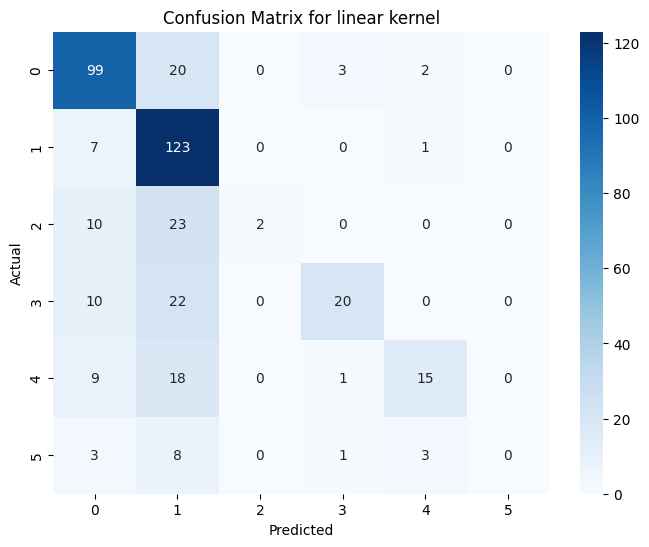


Training with rbf kernel...
Classification report for rbf kernel:

              precision    recall  f1-score   support

           0       0.60      0.67      0.63       124
           1       0.48      0.94      0.64       131
           2       0.00      0.00      0.00        35
           3       1.00      0.06      0.11        52
           4       1.00      0.07      0.13        43
           5       0.00      0.00      0.00        15

    accuracy                           0.53       400
   macro avg       0.51      0.29      0.25       400
weighted avg       0.58      0.53      0.43       400



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


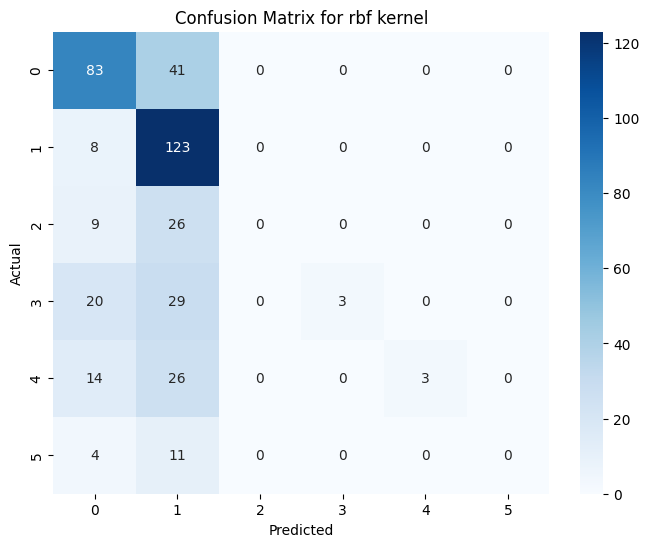


Training with poly kernel...
Classification report for poly kernel:

              precision    recall  f1-score   support

           0       0.88      0.12      0.21       124
           1       0.34      1.00      0.51       131
           2       0.00      0.00      0.00        35
           3       0.00      0.00      0.00        52
           4       0.00      0.00      0.00        43
           5       0.00      0.00      0.00        15

    accuracy                           0.36       400
   macro avg       0.20      0.19      0.12       400
weighted avg       0.39      0.36      0.23       400



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


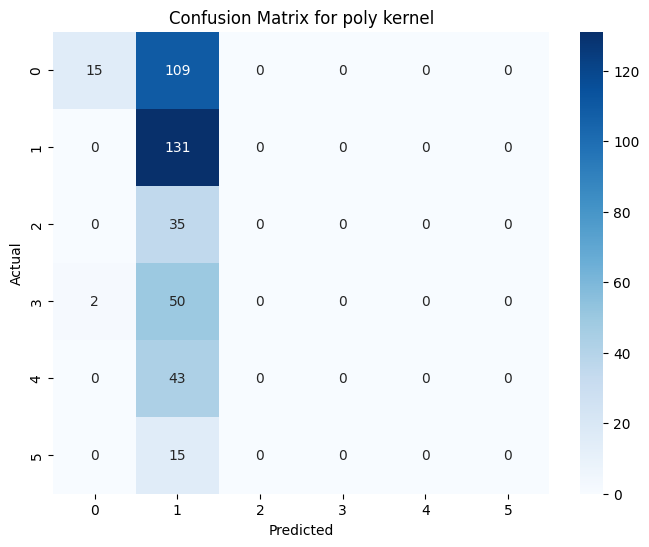


Training with sigmoid kernel...
Classification report for sigmoid kernel:

              precision    recall  f1-score   support

           0       0.71      0.79      0.75       124
           1       0.56      0.94      0.70       131
           2       1.00      0.03      0.06        35
           3       0.83      0.37      0.51        52
           4       0.74      0.33      0.45        43
           5       0.00      0.00      0.00        15

    accuracy                           0.64       400
   macro avg       0.64      0.41      0.41       400
weighted avg       0.68      0.64      0.58       400



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


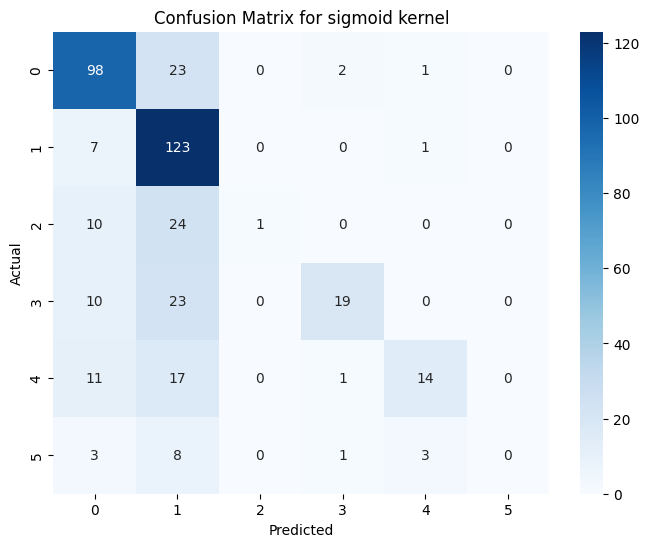

In [9]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import re
from sklearn.model_selection import train_test_split
import numpy as np

kernels = ['linear', 'rbf', 'poly', 'sigmoid']

for kernel in kernels:
    print(f"\nTraining with {kernel} kernel...")
    clf = SVC(kernel=kernel)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    print(f"Classification report for {kernel} kernel:\n")

    target_names_str = [str(cls) for cls in le.classes_]
    print(classification_report(y_test, y_pred, target_names=target_names_str))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names_str, yticklabels=target_names_str)
    plt.title(f'Confusion Matrix for {kernel} kernel')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()